In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
data = pd.read_csv("../data/precios.csv")

dates = data["Date"]
data = data.drop(columns=["Date"])[1:]

tickers = data.columns
num_tickers = len(tickers)

l = np.log(data/data.shift(1))[1:]


# Calculo de VaR historico

historical-VaR: 2.27%


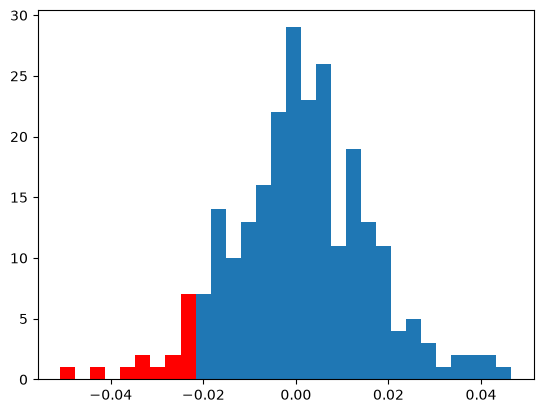

np.float64(0.022741836308792448)

In [3]:
def historical_VaR(portfolio,antelacion=1,risk=0.05,v = True, plot=True):
    x = portfolio/((data.iloc[0].values)*sum(portfolio))
    pre = data.shift(antelacion)
    ganancia = (x*(data - pre))[antelacion:].sum(axis=1)


    var_hist = -ganancia.quantile(risk)
    if v:
        print(f"historical-VaR: {round(var_hist*100,2)}%")
    if plot:
        counts, bins, patches = plt.hist(ganancia, bins=30)
        umbral = -var_hist  # var_hist es positivo, pero el percentil real es negativo
        for patch, left_edge in zip(patches, bins):
            if left_edge < umbral:
                patch.set_facecolor("red")
        plt.show()
    return var_hist

portfolio = np.array([1,1,1,1])
antelacion = 1
historical_VaR(portfolio,antelacion,risk=0.05)

# Calculo de VaR parametrico

In [4]:
def get_norm_params():
    #Calculamos los parametros de la gaussena
    mu = np.zeros(num_tickers)
    Sigma = np.zeros((num_tickers,num_tickers))

    values = l.values
    
    mu = np.mean(values,axis=0)
    Sigma = np.cov(values, rowvar=False, ddof=1)

    return mu, Sigma

def get_lognorm_moments(mu, Sigma):
    """Mapeo vectorizado exacto a momentos lognormales (espacio real)."""
    diag_Sigma = np.diag(Sigma)
    # E[X_i]
    mean_ln = np.exp(mu + diag_Sigma / 2.0)
    # Cov(X_i, X_j) = E[X_i] * E[X_j] * (exp(Sigma_ij) - 1)
    Cov_ln = np.outer(mean_ln, mean_ln) * (np.exp(Sigma) - 1.0)
    return mean_ln, Cov_ln

def parametric_VaR(portfolio,mu,Sigma,antelacion=1,risk=0.05, v=True):
    mean_ln,cov_ln = get_lognorm_moments(antelacion*mu,antelacion*Sigma)


    w = portfolio/sum(portfolio)
    mean_Y = np.dot(w, mean_ln)
    var_Y = np.dot(w, np.dot(cov_ln, w))
    std_Y = np.sqrt(var_Y)
    
    mean_R = mean_Y - 1.0
    std_R = std_Y
    
    # Cuantil Gaussiano para el nivel de riesgo (risk=0.05 -> z ~ -1.64)
    z = norm.ppf(risk) 
    cutoff = mean_R + z * std_R # Cuantil del rendimiento neto
    
    # VaR definido como pérdida relativa (positiva) respecto al valor inicial
    par_VaR = -cutoff
    if v:
        print(f"parametric-VaR: {round(par_VaR,2)*100}%")
    return -par_VaR



In [5]:
norm.ppf(0.05)+1

np.float64(-0.6448536269514729)

parametric-VaR: 4.0%
historical-VaR: 5.64%


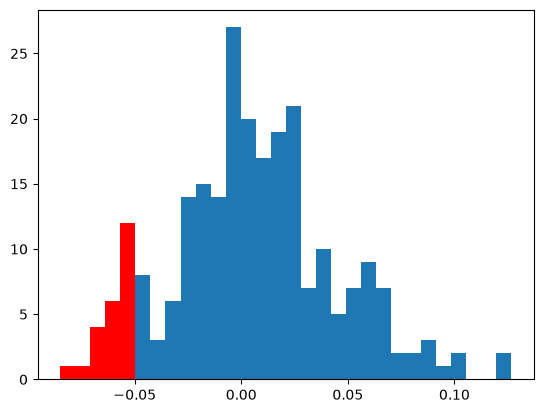

np.float64(0.056360762923628724)

In [6]:
portfolio = np.array([1,1,1,1])
antelacion=5
mu, Sigma = get_norm_params()



parametric_VaR(portfolio,mu,Sigma,antelacion)
historical_VaR(portfolio,antelacion=antelacion)

# Calculo de VaR con Montecarlo

parametric-VaR: 12.0%
historical-VaR: 9.71%


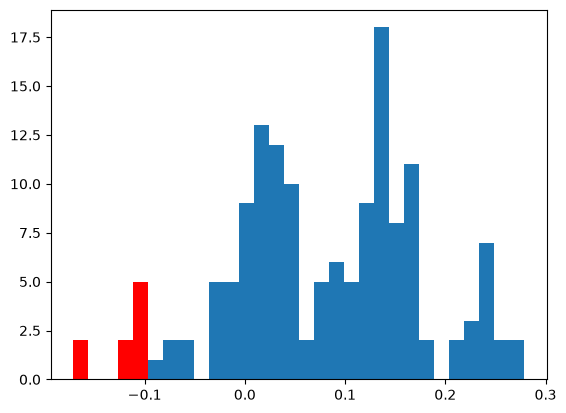

montecarlo-VaR: 10.0%


np.float64(0.10047196675273837)

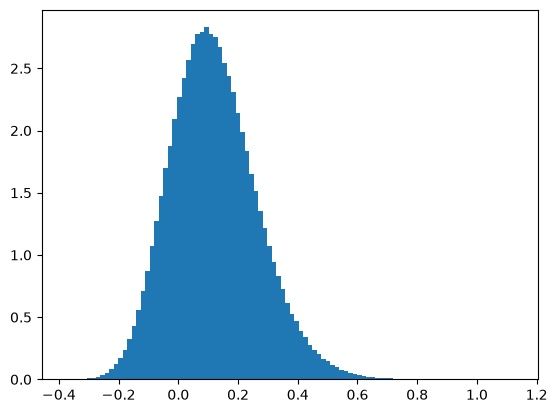

In [7]:
def montecarlo_VaR(portfolio,mu,Sigma,antelacion,N=1000000,risk=0.05,v=True):
    w = portfolio/np.sum(portfolio)
    simulation_result = np.exp(np.random.multivariate_normal(antelacion*mu,antelacion*Sigma,size=N))@w-1

    plt.hist(simulation_result,bins=100,density=True)
    mont_VaR = -np.quantile(simulation_result,q=risk)
    if v:
        print(f"montecarlo-VaR: {round(mont_VaR,2)*100}%")
    return mont_VaR


antelacion = 100
parametric_VaR(portfolio,mu,Sigma,antelacion)
historical_VaR(portfolio,antelacion=antelacion)
montecarlo_VaR(portfolio,mu,Sigma,antelacion=antelacion)

# Calculo de VaR bayesiano

parametric-VaR: 12.0%
historical-VaR: 9.71%


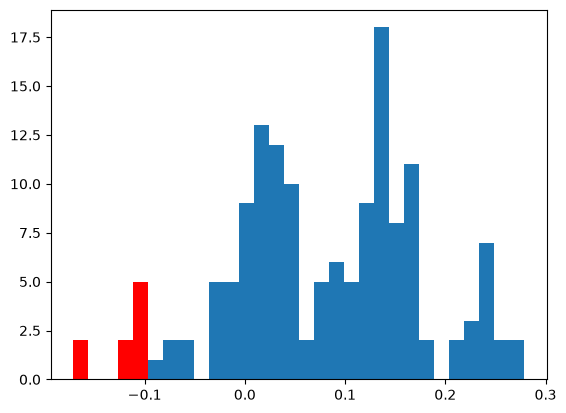

montecarlo-VaR: 10.0%
(4, 4) S shape
bayesian-VaR: 13.0%


<function __main__.bayesian_VaR(portfolio, antelacion, N=1000000, risk=0.05, v=True)>

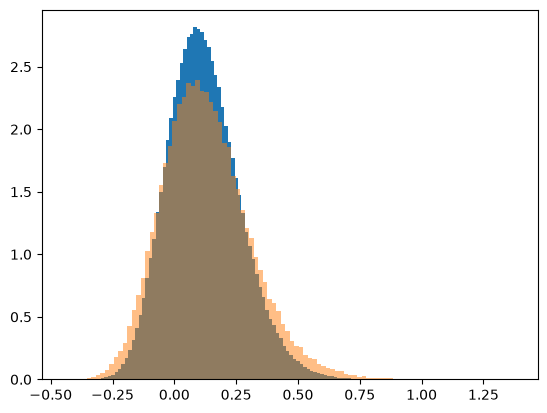

In [9]:
from scipy.stats import invwishart, multivariate_normal

def get_wishart_params(df):
    X = df.values
    N, d = X.shape

    x_bar = np.mean(X,axis=0)

    S = (X- x_bar).T@(X-x_bar)
    print(S.shape, "S shape")

    return x_bar, N, S, N-1


def bayesian_VaR(portfolio,antelacion,N=1000000,risk=0.05,v=True):
    mu_N, kappa_N, psi_N, nu_N = get_wishart_params(l)

    simulation_result = np.zeros(N)
    w = portfolio/sum(portfolio)

    for i in range(N):
        sigma_i = invwishart.rvs(df=nu_N, scale=psi_N)
        cov_mu_i = sigma_i/kappa_N
        mu_i = multivariate_normal.rvs(mean=mu_N, cov=cov_mu_i)

        simulation_result[i] = np.exp(np.random.multivariate_normal(antelacion*mu_i,antelacion*sigma_i))@w -1



    bayes_VaR = -np.quantile(simulation_result,q=risk)

    plt.hist(simulation_result,density=True,bins=100,alpha=0.5)

    if v:
        print(f"bayesian-VaR: {round(bayes_VaR,2)*100}%")
    return bayesian_VaR



antelacion = 100


parametric_VaR(portfolio,mu,Sigma,antelacion)
historical_VaR(portfolio,antelacion=antelacion)
montecarlo_VaR(portfolio,mu,Sigma,antelacion=antelacion)
bayesian_VaR(portfolio,antelacion=antelacion,N=100000)


In [96]:
l.mean(axis=0).values

array([0.00078559, 0.00090348, 0.00131885, 0.00057025])

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, invwishart, multivariate_normal



N = 1000
nu = 249
psi = np.array([[0.06265641,0.0082148,0.01398372,0.00906778],
 [0.0082148, 0.11423648,0.05555553,0.04136152],
 [0.01398372,0.05555553,0.1043816,0.01423809],
 [0.00906778,0.04136152,0.01423809,0.10085425]])

mu =[ 0.00131515, 0.00063461, 0.00214679,-0.00016224]


sigmas = invwishart.rvs(df=nu, scale=psi, size=N)

L = np.linalg.cholesky(sigmas)
z = np.random.standard_normal((N, 4))
print(z.shape)
muestras = mu + np.einsum('nij,nj->ni', L, z)



#print(type(sigmas),sigmas.shape)
#print(sigmas)

#mus = multivariate_normal.rvs(mean=mu,cov = sigmas)



(1000, 4)


In [14]:
cov = sigmas[0,:,:]


np.random.multivariate_normal(mu,cov)

array([ 0.02104447,  0.0009422 , -0.00141841,  0.01640016])